# **Diplomado IA: Deep Learning 1 - Parte 1**. <br> Práctico 11: Redes Recurrentes
---
---

**Profesores:**
- Alain Raymond
- Carlos Aspillaga


El siguiente práctico se debe realizar de forma individual. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Las secciones donde se planteen preguntas de forma explícita, deben ser respondida en celdas de texto, y no se aceptará solo el _output_ de una celda de código como respuesta.

**Nombre alumno:** Roberto Araneda Espinoza

El siguiente práctico contendrá 1 o más actividades a realizar. Algunas actividades corresponderán a escribir código y otras a responder preguntas.

Antes de responder, se recomienda **fuertemente** revisar las secciones previas donde se desarrollan los ejemplos, dado que algunas de las actividades pueden ser completadas reutilizando el mismo código.

---
**IMPORTANTE:** habrá un bonus de 1 décima para todos aquellos alumnos/as que muestren buen orden en sus respuestas (esto aplica a legibilidad de código, buena redacción, formalidad, organización del jupyter notebook, seguimiento de instrucciones, etc). El criterio lo pondrá cada ayudante corrector. La nota máxima obtenible en el laboratorio es 7.0

# Detección de nacionalidad a partir de apellidos utilizando RNNs a nivel de caracteres

Parcialmente basado en:

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://machinelearningmastery.com/lstm-for-time-series-prediction-in-pytorch/

https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

https://pytorch.org/tutorials/beginner/former_torchies/nn_tutorial.html#example-2-recurrent-net

https://colah.github.io/posts/2015-08-Understanding-LSTMs

https://pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html

https://github.com/donnemartin/data-science-ipython-notebooks/blob/master/deep-learning/keras-tutorial/3.2%20RNN%20and%20LSTM.ipynb

http://juditacs.github.io/2018/12/27/masked-attention.html

Construiremos y entrenaremos Redes Neuronales Recurrentes (RNNs) básicas a nivel de caracteres para clasificar palabras. Intencionalmente este laboratorio no utiliza muchas de las funciones de conveniencia de `torchtext`, para permitir observar la operatoria a bajo nivel.

Una RNN a nivel de caracteres lee palabras como una serie de caracteres, emitiendo una predicción y un "estado oculto" en cada paso, alimentando su estado oculto previo en cada siguiente paso. Tomamos la predicción final proyectada linealmente como la salida, para indicar a qué clase pertenece la palabra.

Específicamente, entrenaremos en unos pocos miles de nombres de 18 idiomas de origen, y prediremos a qué idioma pertenece un nombre basándonos en la ortografía.


## Los Datos

Primero vamos a descargar y descomprimir los datos

In [1]:
%matplotlib inline

In [2]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2026-04-26 22:43:41--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 18.160.143.21, 18.160.143.101, 18.160.143.48, ...
Connecting to download.pytorch.org (download.pytorch.org)|18.160.143.21|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.07s   

2026-04-26 22:43:41 (38.3 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/I

Dentro del directorio ``data/names`` existen 18 archivos de texto con nombre ``[Language].txt``. Cada archivo contiene una serie de nombres, un nombre por línea, en su mayoría romanizados (pero aún necesitamos convertir de Unicode a ASCII).

Luego de ejecutar la siguiente celda, terminaremos con un diccionario de listas de nombres por idioma,
``{language: [names ...]}``.

In [3]:
from io import open
import glob
import os
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def findFiles(path):
    return glob.glob(path)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    # example: this code converts 'Ślusàrski' into 'Slusarski
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Ahora tenemos ``category_lines``, un diccionario que asigna cada categoría (idioma) a una lista de líneas (nombres). También llevamos un registro de ``all_categories`` (simplemente una lista de idiomas) y ``n_categories`` para referencia posterior.




In [4]:
print(category_lines['French'][:5])

['Abel', 'Abraham', 'Adam', 'Albert', 'Allard']


### Convirtiendo los Nombres en Tensores

Ahora que tenemos todos los nombres organizados, necesitamos convertirlos en Tensores para poder utilizarlos.

Para representar una sola letra, utilizamos un vector "one-hot" de tamaño ``<1 x n_letras>``. Un vector one-hot está lleno de ceros, excepto por un 1 en el índice de la letra actual, por ejemplo, ``"b" = <0 1 0 0 0 ...>``.

Para formar una palabra, unimos varios de estos vectores en una matriz 2D ``<largo_palabra x 1 x n_letras>``.

Esa dimensión adicional de 1 se debe a que PyTorch asume que todo está en batches - aquí estamos utilizando un tamaño de batch de 1 solamente.


In [5]:
import torch

# Find letter index from all_letters, e.g. "a" = 0

def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

def num_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(letterToTensor('A'))
print(lineToTensor('AlainRaymond').shape)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([12, 1, 57])


## Creando una RNN "vanilla"

Este módulo RNN consta simplemente de 2 capas lineales que operan sobre una entrada y un estado oculto.




**Elman RNN Cell** (vanilla RNN cell)

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/RNN-unrolled.png)

from colah.github.io

<br>

___

<br>

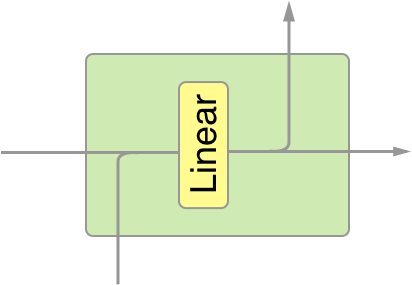


In [6]:
import torch.nn as nn


class RNNCell(nn.Module):
    """
    Implementation of Elman RNN cell (vanilla RNN cell).
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.hidden_size = hidden_size

        # model layers (input to hidden)
        self.x2h = nn.Linear(input_size, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    # RNN forward pass
    def forward(self, input, old_hidden):
        """
        input shaped (batch, input_size)
        hidden shaped (batch, hidden_size)
        """
        # run linear layer on combined inputs (batch, hidden_size)
        hidden = torch.tanh(self.x2h(input) + self.h2h(old_hidden))
        output = self.h2o(hidden)

        return output, hidden

class RNN(nn.Module):
    """
    Implementation of full Elman RNN.
    Executes RNNCell for each of the inputs.
    """
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = RNNCell(input_size, hidden_size, output_size)

    # initialize first hidden state
    def init_hidden(self):
        return torch.zeros(1, self.hidden_size)

    # RNN forward pass
    def forward(self, input, hidden): # batch_size, (largo_secuencia x dim_elemento_secuencia)
        # run cell on ith input (batch, hidden_size)
        output, hidden = self.cell(input, hidden)
        return output, hidden

## Creando una RNN tipo LSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch. Solamente nos preocuparemos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM.

![](https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-chain.png)

from https://colah.github.io/posts/2015-08-Understanding-LSTMs

In [7]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.cell(input, hidden)
        output = self.h2o(hidden[0])
        return output, hidden

## Creando una RNN tipo BiLSTM

Para implementarlo aprovecharemos el módulo LSTM que trae pytorch, que asumiremos será llamado con un input leido de derecha a izquierda y otro de izquierda a derecha. Debemos preocuparnos de retornar los parámetros adecuados y poner la lineal de salida sobre el estado oculto de la LSTM-forward concatenada con la backward.

![](https://miro.medium.com/max/764/1*6QnPUSv_t9BY9Fv8_aLb-Q.png)

Source: https://towardsdatascience.com/understanding-bidirectional-rnn-in-pytorch-5bd25a5dd66

In [8]:
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        # model hyperparameters
        self.bidirectional = True
        self.hidden_size = hidden_size
        self.forward_cell = nn.LSTMCell(input_size, hidden_size)
        self.backward_cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Linear(2*hidden_size, output_size)

    def init_hidden(self):
        return (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)), (torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size))

    # forward pass
    def forward(self, input, hidden):
        """
        input shape (batch, seq_len)
        """
        hidden = self.forward_cell(input[0], hidden[0]), self.backward_cell(input[1], hidden[1])

        # Stack outputs
        outputs_forward = hidden[0][0]
        outputs_backward = hidden[1][0]
        output = self.h2o(torch.cat((outputs_forward, outputs_backward), dim=1))

        return output, hidden



## Ahora analicemos una RNN

In [9]:
n_hidden = 32

rnn = RNN(n_letters, n_hidden, n_categories)

In [10]:
print(num_trainable_parameters(rnn))

3506


Para ejecutar un paso de esta red, necesitamos pasar una entrada (en nuestro caso, el tensor para la letra actual) y un estado oculto anterior (que inicializamos como ceros al principio). Obtendremos la salida (probabilidad de cada idioma, antes de softmax) y un siguiente estado oculto (que conservamos para el siguiente paso).

La razón para omitir la softmax es porque utilizaremos una implementación de CrossEntropy que tiene la softmax incorporada. Por lo mismo, si queremos visualizar las probabilidades tendremos que aplicar una softmax manualmente sobre este vector. En nuestro caso no es necesario pues solo nos interesa quedarnos con el índice del máximo (que será el mismo si aplicamos o no la softmax)




In [11]:
input = letterToTensor('A')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input, hidden)
print(output, output.shape,next_hidden, next_hidden.shape)

torch.Size([1, 57])
tensor([[ 0.0097,  0.1105, -0.1662, -0.1557,  0.0832,  0.1177, -0.1692, -0.0050,
          0.0166, -0.1240,  0.0395,  0.1003, -0.1207, -0.1688, -0.1632, -0.1630,
         -0.2446,  0.2767]], grad_fn=<AddmmBackward0>) torch.Size([1, 18]) tensor([[ 0.0680,  0.0473, -0.0530,  0.0610,  0.1963, -0.0050,  0.0983, -0.0113,
          0.1834,  0.1063,  0.0712, -0.0815,  0.1786,  0.0087, -0.1253,  0.0173,
         -0.2670, -0.2128,  0.0422,  0.0997, -0.0902,  0.0242, -0.0028, -0.2868,
         -0.0091, -0.3292, -0.1078, -0.1808,  0.0862,  0.0637, -0.1311, -0.1796]],
       grad_fn=<TanhBackward0>) torch.Size([1, 32])


In [12]:
input = lineToTensor('Albert')
print(input.shape)
hidden = rnn.init_hidden()

output, next_hidden = rnn(input[0], hidden)
print(output)

torch.Size([6, 1, 57])
tensor([[ 0.0097,  0.1105, -0.1662, -0.1557,  0.0832,  0.1177, -0.1692, -0.0050,
          0.0166, -0.1240,  0.0395,  0.1003, -0.1207, -0.1688, -0.1632, -0.1630,
         -0.2446,  0.2767]], grad_fn=<AddmmBackward0>)


Podemos notar que el output es un Tensor de ``<1 x n_categories>``, que es el vector de probabilidades antes de aplicarle softmax (más grande significa más probable).

Notar que estamos preservando el output correspondiente al último caracter de la palabra (que encapsula toda la información de caractyeres anteriores), con lo cual estamos pudiendo representar cualquier palabra (independiente de su largo) con un vector de tamaño fijo.




## Preparación para el entrenamiento

Primero definiremos una serie de métodos para analizar las salidas y facilitar
el sampleo de ejemplos de entrenamiento




In [13]:
import random

def categoryFromOutput(output):
    # this function returns the category corresponding to the max value
    # in the returned probability Tensor
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample(): #Data Loader
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('{}: {}'.format(line, category))

Nunez: Spanish
Prinsen: Dutch
Meisner: Dutch
Savatier: French
Flores: Spanish
Bonfils: French
Solo: Spanish
Han: Korean
Vu: Vietnamese
Picasso: Spanish


### Entrenamiento

Nota importante: Para evitar tener que trabajar con paddings y detener la iteración de manera distinta para cada elemento del batch según su largo original (antes de paddings) trabajaremos con batches de tamaño 1. Si usted necesita trabajar con batches de mayor tamaño, resulta ser un poco más complejo de implementar (por esa razón lo omitimos de este laboratorio). Para referencia, esto se puede hacer mediante las funcionalidades de torch.nn.utils.rnn llamadas pack_padded_sequence y pad_packed_sequence (tutorial en https://gist.github.com/HarshTrivedi/f4e7293e941b17d19058f6fb90ab0fec)

Para comenzar crearemos nuestro objeto a cargo de evaluar la función de pérdida:





In [14]:
criterion = nn.CrossEntropyLoss()

A continuación creamos una serie de métodos para entrenar, evaluar y graficar resultados de los modelos.

Cada ciclo de entrenamiento hará lo siguiente:

- Creará los tensores de entrada y objetivo.
- Seteará el estado oculto inicial con valores cero.
- Leerá cada letra de la entrada y mantendrá el estado oculto para entregárselo a la siguiente letra.
- Comparará la salida final con el objetivo.
- Realizará el backpropagation.
- Retornará la salida y la función de pérdida.




In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import time
import math

learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor, model):
    hidden = model.init_hidden()

    model.zero_grad()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in model.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate) # SGD HECHO A MANO!!!!

    # optimizer.step()

    return output, loss.item()

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def train_model(model, n_iters=200000, print_every=10000, plot_every=1000):

    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []

    start = time.time()

    for iter in range(1, n_iters + 1):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output, loss = train(category_tensor, line_tensor, model)
        current_loss += loss

        # Print ``iter`` number, loss, name and guess
        if iter % print_every == 0:
            guess, guess_i = categoryFromOutput(output)
            correct = '✓' if guess == category else '✗ (%s)' % category
            print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

        # Add current loss avg to list of losses
        if iter % plot_every == 0:
            all_losses.append(current_loss / plot_every)
            current_loss = 0

    return all_losses, model

def plot_loss(all_losses):
    plt.figure()
    plt.plot(all_losses)


# Just return an output given a line
def evaluate(line_tensor, model):
    hidden = model.init_hidden()

    for i in range(line_tensor.size()[0]):
        if model.bidirectional:
            output, hidden = model((line_tensor[i], line_tensor[line_tensor.size()[0]-i-1]), hidden)
        else:
            output, hidden = model(line_tensor[i], hidden)

    return output


def compute_confusion_matrix(model):
    # Keep track of correct guesses in a confusion matrix
    confusion = torch.zeros(n_categories, n_categories)
    n_confusion = 10000

    # Go through a bunch of examples and record which are correctly guessed
    for i in range(n_confusion):
        category, line, category_tensor, line_tensor = randomTrainingExample()
        output = evaluate(line_tensor, model)
        guess, guess_i = categoryFromOutput(output)
        category_i = all_categories.index(category)
        confusion[category_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(n_categories):
        confusion[i] = confusion[i] / confusion[i].sum()

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.numpy())
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + all_categories, rotation=90)
    ax.set_yticklabels([''] + all_categories)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()

### Ahora a entrenar!

Mediante el método ``train_model`` entrenaremos los tres modelos.

NOTA:  Si tiene restricciones de tiempo, puede reducir el parámetro ``n_iters`` a la mitad para que finalice antes. En este caso usaremos 200K iteraciones.

Luego de entrenado graficaremos la trayectoria de la función de pérdida almacenada en ``all_losses``, y finalmente mostraremos la matriz de confusión asociada a las predicciones de cada modelo, usando ``compute_confusion_matrix``.




In [16]:
n_hidden = 147
model = RNN(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 15s) 2.8276 Kuiper / German ✗ (Dutch)
20000 10% (0m 31s) 3.0655 Caomh / Arabic ✗ (Irish)
30000 15% (0m 46s) 1.7636 Krauss / Dutch ✗ (German)
40000 20% (1m 1s) 0.6166 Dreschner / German ✓
50000 25% (1m 16s) 1.5948 Ritchie / French ✗ (Scottish)
60000 30% (1m 31s) 1.5461 Rodrigues / Dutch ✗ (Portuguese)
70000 35% (1m 47s) 0.1502 Ta / Vietnamese ✓
80000 40% (2m 2s) 0.0067 Assaf / Arabic ✓
90000 45% (2m 17s) 1.1587 Venne / Dutch ✓
100000 50% (2m 32s) 0.5823 Baba / Arabic ✓
110000 55% (2m 48s) 0.0926 Yamakage / Japanese ✓
120000 60% (3m 3s) 0.1346 Rios / Portuguese ✓
130000 65% (3m 19s) 2.2403 Atkin / Russian ✗ (English)
140000 70% (3m 34s) 0.0005 Kijimuta / Japanese ✓
150000 75% (3m 50s) 0.2061 Schneijders / Dutch ✓
160000 80% (4m 5s) 3.1808 D'angelo / Irish ✗ (Italian)
170000 85% (4m 21s) 0.1142 Baz / Arabic ✓
180000 90% (4m 37s) 2.4602 Bock / German ✗ (Czech)
190000 95% (4m 52s) 0.8861 Mateus / Arabic ✗ (Portuguese)
200000 100% (5m 7s) 1.0785 Bosch / Czech ✗ (German)


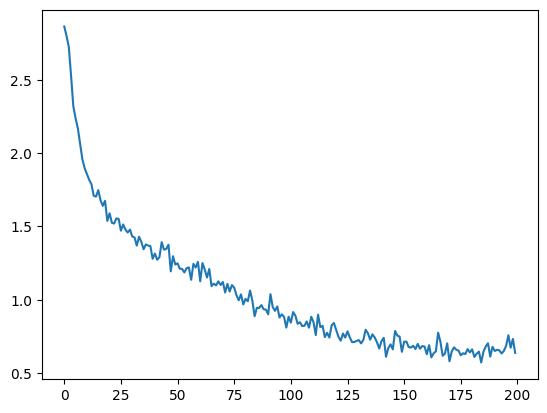

In [17]:
plot_loss(all_losses)

/tmp/ipykernel_22057/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_22057/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


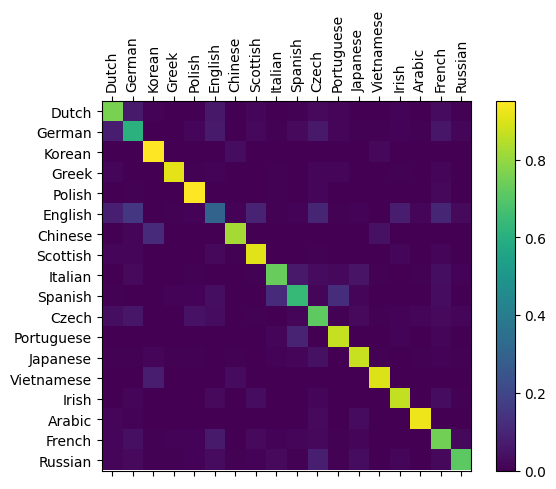

In [18]:
compute_confusion_matrix(model)

In [19]:
n_hidden = 64
model = LSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 23s) 2.9363 Kau / French ✗ (Chinese)
20000 10% (0m 46s) 2.7753 Agosti / Japanese ✗ (Italian)
30000 15% (1m 10s) 1.7540 Ma / Vietnamese ✗ (Korean)
40000 20% (1m 33s) 1.4536 Quyen / Vietnamese ✓
50000 25% (1m 56s) 2.6928 Riedel / German ✗ (Czech)
60000 30% (2m 19s) 0.6354 Ruslanov / Russian ✓
70000 35% (2m 43s) 1.7031 Almasi / Italian ✗ (Arabic)
80000 40% (3m 7s) 0.3023 Gallchobhar / Irish ✓
90000 45% (3m 30s) 4.3273 Brisbois / Greek ✗ (French)
100000 50% (3m 53s) 0.9934 Guerra / Portuguese ✓
110000 55% (4m 16s) 0.4455 Martzinkovsky / Russian ✓
120000 60% (4m 39s) 0.4175 Abaroa / Spanish ✓
130000 65% (5m 3s) 0.8223 Moreno / Portuguese ✓
140000 70% (5m 26s) 2.5932 Vlach / Irish ✗ (Czech)
150000 75% (5m 50s) 2.2532 Speight / German ✗ (English)
160000 80% (6m 13s) 4.1861 Galdus / Portuguese ✗ (Russian)
170000 85% (6m 36s) 0.0919 Chikanatsu / Japanese ✓
180000 90% (7m 0s) 1.1455 Chu / Korean ✗ (Vietnamese)
190000 95% (7m 23s) 1.1463 Kavanagh / English ✗ (Irish)
200000 100% (7m 4

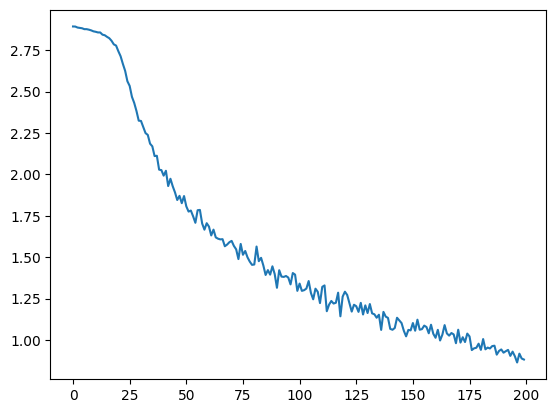

In [20]:
plot_loss(all_losses)

/tmp/ipykernel_22057/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_22057/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


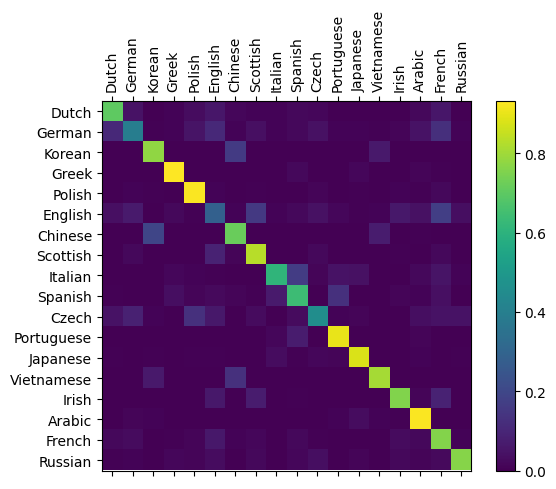

In [21]:
compute_confusion_matrix(model)

In [22]:
n_hidden = 40
model = BiLSTM(n_letters, n_hidden, n_categories)
all_losses, model = train_model(model, n_iters=200000)

10000 5% (0m 40s) 2.8077 Costantini / Portuguese ✗ (Italian)
20000 10% (1m 20s) 2.8208 Parri / Dutch ✗ (Italian)
30000 15% (2m 2s) 2.5924 Carey / German ✗ (Irish)
40000 20% (2m 43s) 1.6383 Diakogeorgiou / Russian ✗ (Greek)
50000 25% (3m 23s) 1.0477 Acquati / Italian ✓
60000 30% (4m 4s) 1.1814 Hofler / German ✓
70000 35% (4m 44s) 1.6532 Preston / Scottish ✗ (English)
80000 40% (5m 26s) 3.8204 Dimmock / Polish ✗ (English)
90000 45% (6m 7s) 0.8095 Min / Chinese ✓
100000 50% (6m 47s) 0.1499 Fujimaki / Japanese ✓
110000 55% (7m 28s) 0.1708 Kedzierski / Polish ✓
120000 60% (8m 8s) 0.9390 Elgin / Russian ✓
130000 65% (8m 48s) 0.4356 Huan / Chinese ✓
140000 70% (9m 30s) 2.1425 Iles / Spanish ✗ (English)
150000 75% (10m 11s) 0.2468 Nakane / Japanese ✓
160000 80% (10m 52s) 2.4467 Aikman / Arabic ✗ (English)
170000 85% (11m 33s) 0.0891 Raghailligh / Irish ✓
180000 90% (12m 15s) 0.0445 Patselas / Greek ✓
190000 95% (12m 56s) 0.1923 Dao / Vietnamese ✓
200000 100% (13m 37s) 0.0261 Kitoaji / Japanese

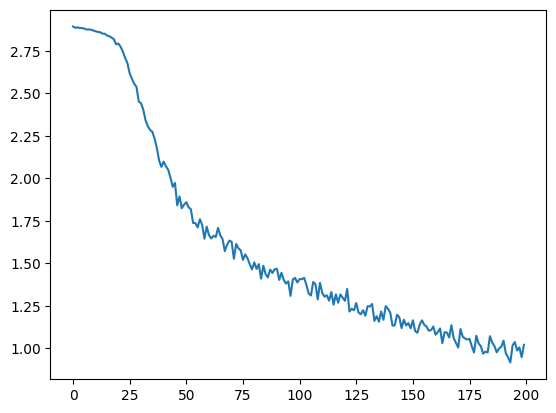

In [23]:
plot_loss(all_losses)

/tmp/ipykernel_22057/938344581.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_22057/938344581.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


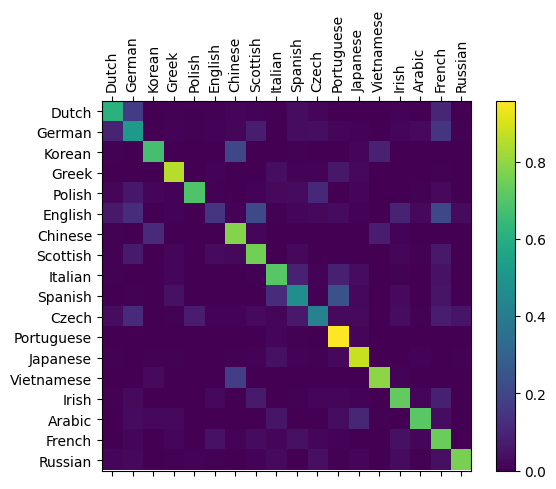

In [24]:
compute_confusion_matrix(model)

En este caso podemos ver que no existe demasiada diferencia entre las tres arquitecturas (aunque para saberlo con certeza habría que hacer una mejor búsqueda de hiperparámetros y evaluar correctamente, lo cual no era parte de este laboratorio).
A primera vista vemos que los tres modelos parecen comportarse de manera similar. Una posible explicación es debido a que este dataset es muy pequeño y no logra aprovechar las capacidades de modelos más sofisticados como la LSTM y la BiLSTM. En escenarios más realistas (más datos y tareas más desafiantes) es esperable que la LSTM supere largamente a la RNN simple, y que la BiLSTM supere a la LSTM.

## Evaluación manual

Por completitud, a continuación dejamos un código para evaluar el modelo en ejemplos definidos manualmente, por si usted desea utilizarlo de esta manera.




In [25]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line), model)

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Satoshi')
predict("Muñoz")
predict("Raymond")


> Dovesky
(6.48) Czech
(6.25) Russian
(5.23) Polish

> Jackson
(5.94) Scottish
(4.68) English
(3.09) German

> Satoshi
(7.72) Japanese
(5.68) Arabic
(2.94) Italian

> Muñoz
(4.89) Spanish
(3.88) Portuguese
(2.18) Polish

> Raymond
(4.12) French
(3.83) English
(3.16) Scottish


# Actividad 1

- Mencione la dimensionalidad oculta de los 3 modelos ejecutados en este laboratorio, calcule su cantidad de parámetros y explique por qué no sería justo utilizar dimensionalidad oculta pareja para todos los modelos.

In [26]:
n_letters = 57
n_categories = 18

print("Conteo de parámetros (los 3 modelos del lab):")
for name, cls, n_h in [("RNN vanilla", RNN, 147), ("LSTM", LSTM, 64), ("BiLSTM", BiLSTM, 40)]:
    m = cls(n_letters, n_h, n_categories)
    print(f"  {name:14s} n_hidden={n_h:3d}  ->  {num_trainable_parameters(m):>6,d} params")

print("\nContrafactual: si usáramos n_hidden=64 para los 3:")
for name, cls in [("RNN vanilla", RNN), ("LSTM", LSTM), ("BiLSTM", BiLSTM)]:
    m = cls(n_letters, 64, n_categories)
    print(f"  {name:14s} n_hidden= 64  ->  {num_trainable_parameters(m):>6,d} params")

Conteo de parámetros (los 3 modelos del lab):
  RNN vanilla    n_hidden=147  ->  32,946 params
  LSTM           n_hidden= 64  ->  32,658 params
  BiLSTM         n_hidden= 40  ->  33,138 params

Contrafactual: si usáramos n_hidden=64 para los 3:
  RNN vanilla    n_hidden= 64  ->   9,042 params
  LSTM           n_hidden= 64  ->  32,658 params
  BiLSTM         n_hidden= 64  ->  65,298 params


# **Respuesta:**

Los 3 modelos del laboratorio se ejecutan con dimensionalidades ocultas distintas:

*   RNN vanilla (Elman): n_hidden = 147
*   LSTM: n_hidden = 64
*   BiLSTM: n_hidden = 40

Calculando con **num_trainable_parameters(model)**, la cantidad de parámetros entrenables de cada modelo es:

*   RNN vanilla (n_hidden = 147): 32,946 parámetros
*   LSTM (n_hidden = 64): 32,658 parámetros
*   BiLSTM (n_hidden = 40): 33,138 parámetros

**Por qué no sería justo usar el mismo n_hidden para los tres modelos:**

No sería justo porque las arquitecturas tienen estructuras internas distintas que escalan de manera muy diferente con n_hidden:

*   La RNN vanilla tiene una sola transformación recurrente.
*   La LSTM tiene cuatro transformaciones recurrentes (input gate, forget gate, candidate, output gate). Eso multiplica por 4 los pesos sobre H.
*   La BiLSTM tiene dos LSTMs (forward + backward). Eso multiplica por 2 sobre la LSTM, es decir por 8 respecto a la RNN vanilla


# Actividad 2

Agregue otra capa lineal con una ReLU al clasificador del modelo de LSTM (no bidireccional) como se muestra en la figura.

Pruebe variantes de 50, 150 y 300 neuronas en la capa oculta.

- Grafique la pérdida para las 3 y comente.
- Calcule la cantidad de parámetros de los tres modelos y comente.

*(Consejo: debe tener dos capas `linear`, y se necesita una activación entre ellas)*

| A la izquierda se muestra diagrama actual de salida de la red. Implementar el de la izquierda agregando otra capa. |
| :--: |
| 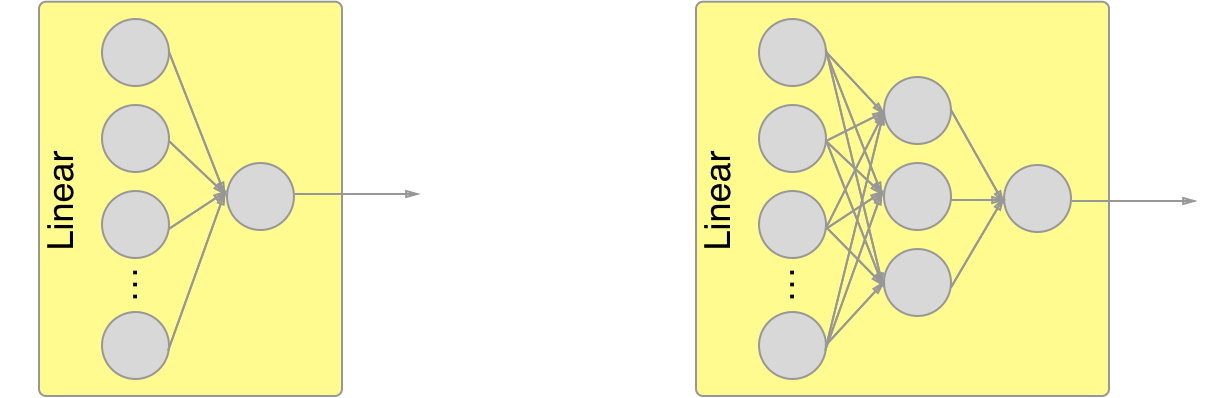 |



In [27]:
class LSTM_MLP(nn.Module):
    def __init__(self, input_size, hidden_size, mlp_hidden, output_size):
        super().__init__()
        self.bidirectional = False
        self.hidden_size = hidden_size
        self.cell = nn.LSTMCell(input_size, hidden_size)
        self.h2o = nn.Sequential(
            nn.Linear(hidden_size, mlp_hidden),
            nn.ReLU(),
            nn.Linear(mlp_hidden, output_size),
        )

    def init_hidden(self):
        return torch.zeros(1, self.hidden_size), torch.zeros(1, self.hidden_size)

    def forward(self, input, hidden):
        hidden = self.cell(input, hidden)
        output = self.h2o(hidden[0])
        return output, hidden


=== mlp_hidden = 50 ===
Parámetros: 35,656
10000 5% (0m 27s) 2.9321 Araullo / French ✗ (Portuguese)
20000 10% (0m 54s) 2.8339 Vu / English ✗ (Vietnamese)
30000 15% (1m 22s) 2.7806 Sztegon / Dutch ✗ (Czech)
40000 20% (1m 49s) 2.8357 Benitez / Russian ✗ (Spanish)
50000 25% (2m 17s) 1.2006 Ta / Chinese ✗ (Vietnamese)
60000 30% (2m 44s) 1.8391 Freitas / Greek ✗ (Portuguese)
70000 35% (3m 11s) 2.1719 Rocha / Czech ✗ (Spanish)
80000 40% (3m 39s) 1.1625 Finnegan / Irish ✓
90000 45% (4m 7s) 1.1104 Mercier / French ✓
100000 50% (4m 35s) 0.0650 Sklavenitis / Greek ✓
110000 55% (5m 3s) 1.0677 Shuo / Vietnamese ✗ (Chinese)
120000 60% (5m 31s) 1.5126 Maguire / Japanese ✗ (Irish)
130000 65% (5m 58s) 0.2613 Sook / Korean ✓
140000 70% (6m 26s) 0.3898 Pereira / Portuguese ✓
150000 75% (6m 53s) 1.3621 De fiore / French ✗ (Italian)
160000 80% (7m 21s) 0.8172 Ocasek / Czech ✓
170000 85% (7m 48s) 0.3171 Fei / Chinese ✓
180000 90% (8m 15s) 0.4763 Meeuwissen / Dutch ✓
190000 95% (8m 43s) 0.1816 Wan / Chines

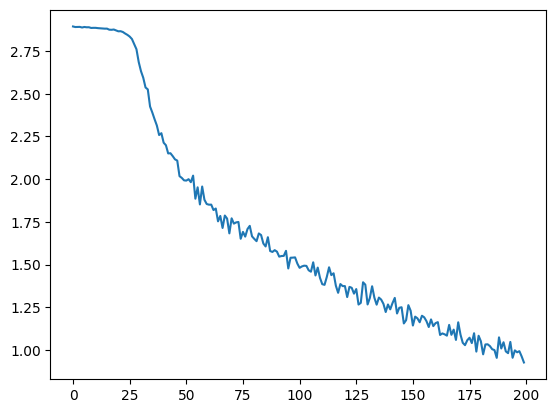

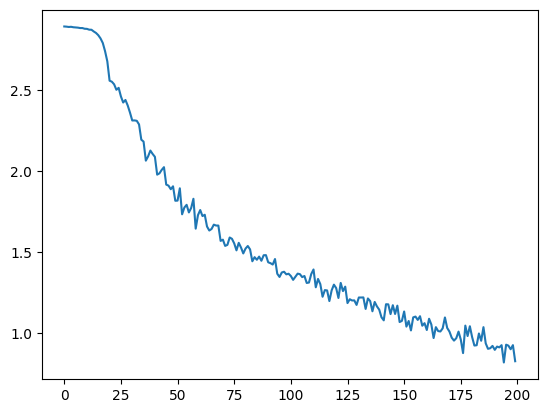

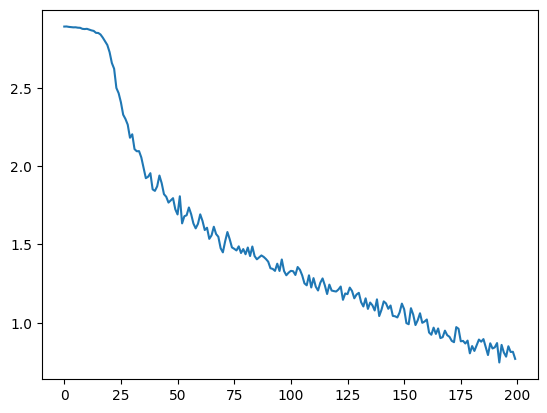

In [28]:
for mlp_hidden in [50, 150, 300]:
    print(f"\n=== mlp_hidden = {mlp_hidden} ===")
    model = LSTM_MLP(n_letters, 64, mlp_hidden, n_categories)
    print(f"Parámetros: {num_trainable_parameters(model):,}")
    all_losses, model = train_model(model, n_iters=200000)
    plot_loss(all_losses)

# **Respuesta a la Actividad 2**

Se entrenan tres variantes del clasificador del LSTM (no bidireccional, n_hidden = 64), reemplazando la capa lineal final por un MLP de dos capas con activación ReLU intermedia. Las tres variantes usan mlp_hidden ∈ {50, 150, 300}.

**Cantidad de parámetros**

*   LSTM + MLP head con mh = 50: 35,656 parámetros (head solo: 4,168)
*   LSTM + MLP head con mh = 150: 43,956 parámetros (head solo: 12,468)
*   LSTM + MLP head con mh = 300: 56,406 parámetros (head solo: 24,918)

**Comentarios sobre los parámetros**

El head crece linealmente con mlp_hidden: cada neurona adicional añade aproximadamente 83 parámetros (64 entradas + 18 salidas + 2 sesgos). La variante con mh = 300 casi duplica el tamaño del modelo respecto al LSTM original (56K vs 33K parámetros). Casi todo ese gasto extra está concentrado en el clasificador, no en el backbone recurrente. El backbone LSTM (donde realmente ocurre el aprendizaje secuencial) no cambia entre las tres variantes — lo único que se está modificando es la capacidad del clasificador final que recibe el último estado oculto.

**Comentarios sobre las curvas de pérdida**

Comparando las tres curvas tras 200,000 iteraciones de entrenamiento:

*   mh = 50 (35,656 params): plateau plano hasta iter ~25K, caída brusca entre 25K–50K, descenso gradual hasta una pérdida final suavizada de aproximadamente 0.95–1.00.
*   mh = 150 (43,956 params): plateau más corto (hasta iter ~18–20K), descenso continuo desde ahí sin escalón pronunciado, pérdida final suavizada de aproximadamente 0.85–0.90.
*   mh = 300 (56,406 params): plateau corto (~18–20K iters), caída más pronunciada entre iter 20K–35K (de 2.85 a ~1.8), descenso continuo hasta una pérdida final suavizada de aproximadamente 0.75–0.85.

Existe una mejora pequeña pero consistente al aumentar mlp_hidden: la diferencia es de aproximadamente 0.20 puntos de loss entre el extremo (mh = 50) y el más grande (mh = 300).

**Conclusión**

Aumentar la capacidad del clasificador final mejora la pérdida, pero la ganancia por parámetro extra es marginal: pasar de 33K parámetros (LSTM original) a 56K parámetros (mh = 300) compra una mejora de aproximadamente 0.10–0.20 puntos de loss.
